In [5]:
import xarray as xr   # xarray pacckage for netcdf io and data processing
import glob           # allow unix shell like text
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pylab import plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from scipy.signal import savgol_filter
#import seaborn as sns

xr.set_options(display_style="html")
%matplotlib inline

import os
import netCDF4
import datetime
import calendar
import numpy as np

Text(0.5, 1.0, 'Daily LAI interpolated from observation')

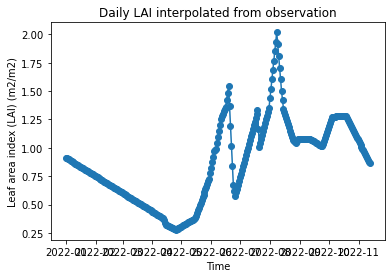

In [4]:
# Creat LAI netcdf file from observed LAI interpolated to daily for SVM to use (This is a more reasonable option)

year=2022

lai =pd.read_csv('/home/tang/Documents/FiON/obs/qvidja/sentinel_whole/qvidja_ec_lai.csv', index_col=None, header=0, sep=',')
lai['Date']=pd.to_datetime(lai['Date'])

lai_r=lai.resample('D', on="Date").mean()
lai_r

lai_d=lai_r["lai"].interpolate(method="time")


time_lai=pd.to_datetime(lai_d.index)

date_b=str(year)+'-01-01'
date_e=str(year+1)+'-01-01'
mask_obs = ((time_lai >= date_b) 
         & (time_lai < date_e))

plt.scatter(lai_d.loc[mask_obs].index,lai_d.loc[mask_obs], label="obs")
plt.plot(lai_d.loc[mask_obs].index,lai_d.loc[mask_obs], label="obs")


plt.xlabel("Time")
plt.ylabel("Leaf area index (LAI) (m2/m2)")
plt.title("Daily LAI interpolated from observation")
#plt.legend(loc=(0.1,0.72),prop={'size': 8})

In [62]:
# Open the surface data file to modify

year=2020

os.remove('/home/tang/Documents/noresm-land-sites-platform/resources/SVMC/data/FieldObs_Qvidja.'+str(year)+'.lai.nc')
nc = netCDF4.Dataset('/home/tang/Documents/noresm-land-sites-platform/resources/SVMC/data/FieldObs_Qvidja.'+str(year)+'.lai.nc', 'w')

# Global attributes
nc.title = 'Leaf area index - Qvidja'
nc.summary = ('All information related to management')
nc.keywords = 'Crop management'
nc.license = ('This work is licensed under a Creative Commons '
              'Attribution 4.0 International License.')
nc.references = ('FiON')
nc.source = 'from sentinel-2 LAI product '
nc.Conventions = 'CF-1.6'
nc.institution = 'Finnish Meteorological Institute (FMI)'
nc.history = '{0} creation of lai - Qvidja netcdf file.'.format(
              datetime.datetime.now().strftime("%Y-%m-%d")
             )

# -- Create dimensions
lat_dim = nc.createDimension('latitude', 1)
lon_dim = nc.createDimension('longitude', 1)
tim_dim = nc.createDimension('time', 365 + calendar.isleap(year))

# Create variables
lat_var = nc.createVariable('latitude', np.float64, ('latitude'))
lat_var.units = 'degrees_north'
lat_var.standard_name = 'latitude'
#lat_var.axis = 'Y'

lon_var = nc.createVariable('longitude', np.float64, ('longitude'))
lon_var.units = 'degrees_east'
lon_var.standard_name = 'longitude'
#lon_var.axis = 'X'

time_var = nc.createVariable('time', np.float64, ('time'))
time_var.standard_name = 'time'
time_var.calendar = 'gregorian'
#time_var.time_step = 'Monthly'
time_var.units = 'days since '+str(year)+'-01-01 00:00:00'
#time_var.axis = 'T'

# -- Create management variables:

lai_var = nc.createVariable('LAI', np.float64, ('time', 'latitude', 'longitude'),
                           fill_value=9999)
lai_var.units      = 'm2 m-2'
lai_var.long_name  = 'Leaf area index'
lai_var.short_name = 'LAI'

# -- Load values: time
#date_200506 = int((datetime.datetime(2005,6,1) - datetime.datetime(1970,1,1)).total_seconds())
time_values = np.arange(0.0,365+calendar.isleap(year),1.0)
time_var[:] = time_values 

# -- Load values: latitude and longitude
lat_values = [60.2942641727575]
lon_values = [22.3908939321246]
lat_var[:] = lat_values
lon_var[:] = lon_values

# -- Load values: management info, (1) create empty arrays of management variables
lai_val  = np.zeros(365+calendar.isleap(year), dtype="float64") 

dt_start        = lai_d.loc[mask_obs].index[0]
dt_end          = lai_d.loc[mask_obs].tail(1).index[0]
time_index_start= (dt_start - datetime.datetime(year,1,1, tzinfo=datetime.timezone.utc)).days
time_index_end  = (dt_end - datetime.datetime(year,1,1, tzinfo=datetime.timezone.utc)).days

lai_val[time_index_start:time_index_end+1] = lai_d.loc[mask_obs]
 
lai_var[:,0,0]  = lai_val[:]


nc.close()

ValueError: could not broadcast input array from shape (317,) into shape (0,)

In [ ]:
# Option of using GP interpolated LAI:

python laigp.py --harvest-date=2022-06-21 --harvest-date=2022-08-23 --year 2022 --plot "/home/tang/Documents/FiON/obs/qvidja/sentinel/2022_qvidja_ec_lai.csv" --output-stats test.csv
python laigp.py --harvest-date=2021-06-14 --year 2021 --plot "/home/tang/Documents/FiON/obs/qvidja/sentinel/2021_qvidja_ec_lai.csv" --output-stats qvidja_2021_gp.csv
python laigp.py --harvest-date=2020-06-23 --harvest-date=2020-08-28 --year 2020 --plot "/home/tang/Documents/FiON/obs/qvidja/sentinel/2020_qvidja_ec_lai.csv" --output-stats qvidja_2020_gp.csv
python laigp.py --harvest-date=2020-06-23 --harvest-date=2020-08-28 --year 2020 --plot "/home/tang/Documents/FiON/obs/qvidja/sentinel/2020_qvidja_ec_lai.csv" --output-stats qvidja_2020_gp.csv --random-seed=1234
python laigp.py --harvest-date=2019-06-11 --harvest-date=2019-08-20 --year 2019 --plot "/home/tang/Documents/FiON/obs/qvidja/sentinel/2019_qvidja_ec_lai.csv" --output-stats qvidja_2019_gp.csv
python laigp.py --harvest-date=2018-06-12 --harvest-date=2018-09-23 --year 2018 --plot "/home/tang/Documents/FiON/obs/qvidja/sentinel/2018_qvidja_ec_lai.csv" --output-stats qvidja_2018_gp.csv
python laigp.py --harvest-date=2018-06-12 --harvest-date=2018-08-21 --harvest-date=2018-09-23 --year 2018 --plot "/home/tang/Documents/FiON/obs/qvidja/sentinel/2018_qvidja_ec_lai.csv" --output-stats qvidja_2018_gp.csv


In [ ]:
# Read and write lai data:
 python laigp.py --harvest-mon=6 --harvest-mon=9 --year 2018 --plot "/home/tang/Documents/FiON/obs/qvidja/sentinel/2018_qvidja_ec_lai.csv" --output-stats qvidja_2018_gp_month.csv
 python laigp.py --harvest-mon=6 --harvest-mon=8 --year 2019 --plot "/home/tang/Documents/FiON/obs/qvidja/sentinel/2019_qvidja_ec_lai.csv" --output-stats qvidja_2019_gp_month.csv 
 python laigp.py --harvest-mon=6 --harvest-mon=8 --year 2020 --plot "/home/tang/Documents/FiON/obs/qvidja/sentinel/2020_qvidja_ec_lai.csv" --output-stats test2.csv
 python laigp.py --harvest-mon=6 --year 2021 --plot "/home/tang/Documents/FiON/obs/qvidja/sentinel/2021_qvidja_ec_lai.csv" --output-stats qvidja_2021_gp_month.csv
 python laigp.py --harvest-mon=6 --harvest-mon=8 --year 2022 --plot "/home/tang/Documents/FiON/obs/qvidja/sentinel/2022_qvidja_ec_lai.csv" --output-stats qvidja_2022_gp_month.csv



Text(0.5, 1.0, 'Daily LAI interpolated from observation')

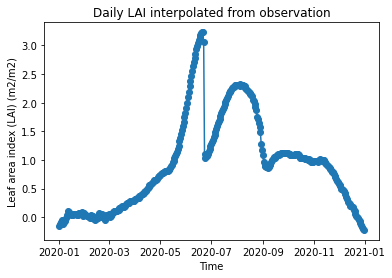

In [6]:
# Creat LAI netcdf file from observed LAI interpolated to daily for SVM to use (This is a more reasonable option)

year=2020

lai =pd.read_csv('/home/tang/Documents/noresm-land-sites-platform/resources/SVMC_FULL/python/ecotools/qvidja_'+str(year)+'_gp_month.csv', index_col=0, header=0, sep=',')
lai.index=pd.to_datetime(lai.index)


lai_d=lai["Q50"]

time_lai=lai_d.index

date_b=str(year)+'-01-01'
date_e=str(year+1)+'-01-01'
mask_obs = ((time_lai >= date_b) 
         & (time_lai < date_e))

plt.scatter(lai_d.loc[mask_obs].index,lai_d.loc[mask_obs], label="obs")
plt.plot(lai_d.loc[mask_obs].index,lai_d.loc[mask_obs], label="obs")


plt.xlabel("Time")
plt.ylabel("Leaf area index (LAI) (m2/m2)")
plt.title("Daily LAI interpolated from observation")
#plt.legend(loc=(0.1,0.72),prop={'size': 8})

In [8]:
# Open the surface data file to modify

year=2020

os.remove('/home/tang/Documents/noresm-land-sites-platform/resources/SVMC/data/FieldObs_Qvidja.'+str(year)+'.lai.gp.nc')
nc = netCDF4.Dataset('/home/tang/Documents/noresm-land-sites-platform/resources/SVMC/data/FieldObs_Qvidja.'+str(year)+'.lai.gp.nc', 'w')

# Global attributes
nc.title = 'Leaf area index - Qvidja'
nc.summary = ('All information related to management')
nc.keywords = 'Crop management'
nc.license = ('This work is licensed under a Creative Commons '
              'Attribution 4.0 International License.')
nc.references = ('FiON')
nc.source = 'from sentinel-2 LAI product '
nc.Conventions = 'CF-1.6'
nc.institution = 'Finnish Meteorological Institute (FMI)'
nc.history = '{0} creation of lai - Qvidja netcdf file.'.format(
              datetime.datetime.now().strftime("%Y-%m-%d")
             )

# -- Create dimensions
lat_dim = nc.createDimension('latitude', 1)
lon_dim = nc.createDimension('longitude', 1)
tim_dim = nc.createDimension('time', 365 + calendar.isleap(year))

# Create variables
lat_var = nc.createVariable('latitude', np.float64, ('latitude'))
lat_var.units = 'degrees_north'
lat_var.standard_name = 'latitude'
#lat_var.axis = 'Y'

lon_var = nc.createVariable('longitude', np.float64, ('longitude'))
lon_var.units = 'degrees_east'
lon_var.standard_name = 'longitude'
#lon_var.axis = 'X'

time_var = nc.createVariable('time', np.float64, ('time'))
time_var.standard_name = 'time'
time_var.calendar = 'gregorian'
#time_var.time_step = 'Monthly'
time_var.units = 'days since '+str(year)+'-01-01 00:00:00'
#time_var.axis = 'T'

# -- Create management variables:

lai_var = nc.createVariable('LAI', np.float64, ('time', 'latitude', 'longitude'),
                           fill_value=9999)
lai_var.units      = 'm2 m-2'
lai_var.long_name  = 'Leaf area index'
lai_var.short_name = 'LAI'

# -- Load values: time
#date_200506 = int((datetime.datetime(2005,6,1) - datetime.datetime(1970,1,1)).total_seconds())
time_values = np.arange(0.0,365+calendar.isleap(year),1.0)
time_var[:] = time_values 

# -- Load values: latitude and longitude
lat_values = [60.2942641727575]
lon_values = [22.3908939321246]
lat_var[:] = lat_values
lon_var[:] = lon_values

# -- Load values: management info, (1) create empty arrays of management variables
lai_val  = np.zeros(365+calendar.isleap(year), dtype="float64") 

dt_start        = lai_d.loc[mask_obs].index[0]
dt_end          = lai_d.loc[mask_obs].tail(1).index[0]
time_index_start= (dt_start - datetime.datetime(year,1,1)).days
time_index_end  = (dt_end - datetime.datetime(year,1,1)).days

lai_val[time_index_start:time_index_end+1] = lai_d.loc[mask_obs].where(lai_d>=0,0.0)
 
lai_var[:,0,0]  = lai_val[:]

nc.close()